# Factored MDP demo: weather and an umbrella

This notebook builds a small transition model with two qualitatively different regularities:

- **Weather** is uncontrollable and evolves according to $P(w'\mid w)$.
- **Umbrella state** is controllable and evolves according to $P(u'\mid u,w,a)$.

The factored model combines them without constructing a separate joint table:

$$P(w',u'\mid w,u,a)=P(w'\mid w)P(u'\mid u,w,a).$$

We will verify that identity directly, exhaustively check normalization, and compare the effects of opening and closing the umbrella.

In [1]:
from itertools import product
from math import isclose
from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    """Find the repository whether the kernel starts in the root or notebooks/."""
    for candidate in (start, *start.parents):
        if (candidate / "scripts" / "mdp.py").is_file():
            return candidate
    raise FileNotFoundError("Could not find scripts/mdp.py above the kernel's working directory")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.mdp import FactoredMDP, TabularMDP, Variable

print("Loaded scripts from the repository checkout.")

Loaded scripts from the repository checkout.


## Variables

Each `Variable` has a name and a finite domain. The action is a parent variable: it conditions transitions but is not itself predicted by this MDP.

In [2]:
WEATHER_VALUES = ("sunny", "rainy")
UMBRELLA_VALUES = ("closed", "open")
ACTION_VALUES = ("open", "close")

weather = Variable("weather", WEATHER_VALUES)
umbrella = Variable("umbrella", UMBRELLA_VALUES)
action = Variable("action", ACTION_VALUES)

weather, umbrella, action

(Variable(name='weather', domain=('sunny', 'rainy')),
 Variable(name='umbrella', domain=('closed', 'open')),
 Variable(name='action', domain=('open', 'close')))

## An uncontrollable factor

Weather has no action parent. Its rows describe persistence with occasional changes, so the agent can learn and predict it but cannot affect it.

In [3]:
weather_factor = TabularMDP(
    variables=(weather,),
    transitions=(
        (
            {"weather": "sunny"},
            {},
            (({"weather": "sunny"}, 0.80), ({"weather": "rainy"}, 0.20)),
        ),
        (
            {"weather": "rainy"},
            {},
            (({"weather": "sunny"}, 0.30), ({"weather": "rainy"}, 0.70)),
        ),
    ),
)

list(weather_factor.transition_distribution({"weather": "rainy"}).items())

[(Assignment({'weather': 'sunny'}), 0.3),
 (Assignment({'weather': 'rainy'}), 0.7)]

## A controllable factor

Umbrella state depends on its current position, weather, and action. Opening usually leaves the umbrella open, while closing usually leaves it closed; rainy weather is an illustrative proxy for adverse handling conditions, not a calibrated physical model.

In [4]:
umbrella_rows = (
    # current umbrella, weather and action parents, distribution over next umbrella
    ({"umbrella": "closed"}, {"weather": "sunny", "action": "open"},  (({"umbrella": "closed"}, 0.05), ({"umbrella": "open"}, 0.95))),
    ({"umbrella": "closed"}, {"weather": "rainy", "action": "open"},  (({"umbrella": "closed"}, 0.25), ({"umbrella": "open"}, 0.75))),
    ({"umbrella": "open"},   {"weather": "sunny", "action": "open"},  (({"umbrella": "closed"}, 0.02), ({"umbrella": "open"}, 0.98))),
    ({"umbrella": "open"},   {"weather": "rainy", "action": "open"},  (({"umbrella": "closed"}, 0.10), ({"umbrella": "open"}, 0.90))),
    ({"umbrella": "closed"}, {"weather": "sunny", "action": "close"}, (({"umbrella": "closed"}, 1.00),)),
    ({"umbrella": "closed"}, {"weather": "rainy", "action": "close"}, (({"umbrella": "closed"}, 1.00),)),
    ({"umbrella": "open"},   {"weather": "sunny", "action": "close"}, (({"umbrella": "closed"}, 0.95), ({"umbrella": "open"}, 0.05))),
    ({"umbrella": "open"},   {"weather": "rainy", "action": "close"}, (({"umbrella": "closed"}, 0.85), ({"umbrella": "open"}, 0.15))),
)

umbrella_factor = TabularMDP(
    variables=(umbrella,),
    parent_variables=(weather, action),
    transitions=umbrella_rows,
)

list(
    umbrella_factor.transition_distribution(
        {"umbrella": "closed"},
        {"weather": "rainy", "action": "open"},
    ).items()
)

[(Assignment({'umbrella': 'closed'}), 0.25),
 (Assignment({'umbrella': 'open'}), 0.75)]

## Compose the factors

`weather` is predicted by one factor and used as a parent by the other. The factored model therefore exposes only `action` as an external parent; it gets the umbrella factor's weather context from the current joint state.

In [5]:
world = FactoredMDP((weather_factor, umbrella_factor))

print("Joint variables:", tuple(variable.name for variable in world.variables))
print("External parents:", tuple(variable.name for variable in world.parent_variables))

Joint variables: ('weather', 'umbrella')
External parents: ('action',)


## Visualize the transition structure

The default `factor` view is a two-slice graph: current variables and external parents at time $t$ feed explicit transition-factor nodes, which point to predicted variables at time $t+1$. Keeping factor nodes visible represents the model's declared factorization without asserting finer-grained conditional independencies.

**Figure 1. Weather–umbrella transition structure.** Blue circles are current-state variables, the orange diamond is the external action parent, gray squares are transition factors, and green circles are next-state variables. Solid arrows encode state/factor or prediction links; the dashed arrow encodes external-parent conditioning. Node labels identify variables, time slices, and domains. Axes are omitted because coordinates carry no scientific meaning.

Nodes:
  ('current', 'weather'): current — weather (t)
  ('next', 'weather'): next — weather (t+1)
  ('current', 'umbrella'): current — umbrella (t)
  ('next', 'umbrella'): next — umbrella (t+1)
  ('parent', 'action'): parent — action (t)
  ('factor', (0,)): factor — P(weather′ | weather)
  ('factor', (1,)): factor — P(umbrella′ | umbrella, weather, action)

Edges:
  ('current', 'weather') -> ('factor', (0,)): current_state
  ('current', 'weather') -> ('factor', (1,)): internal_parent
  ('current', 'umbrella') -> ('factor', (1,)): current_state
  ('parent', 'action') -> ('factor', (1,)): external_parent
  ('factor', (0,)) -> ('next', 'weather'): prediction
  ('factor', (1,)) -> ('next', 'umbrella'): prediction


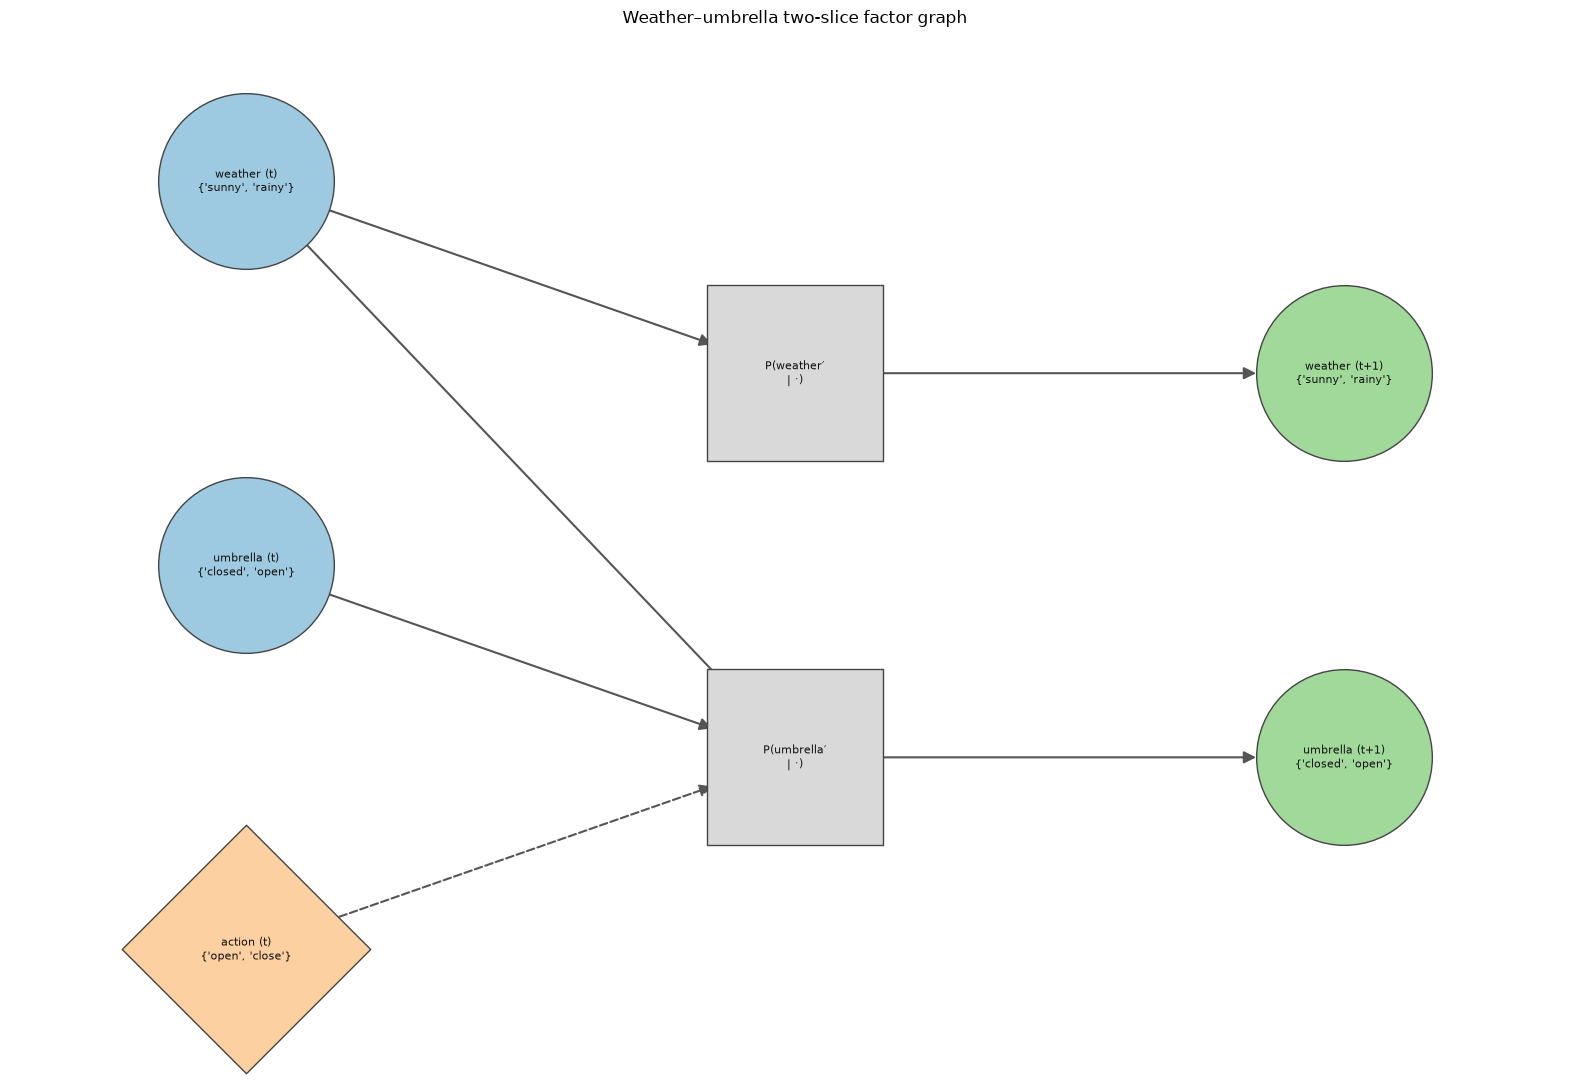

In [6]:
%matplotlib inline

import matplotlib.pyplot as plt

graph = world.to_networkx()

print("Nodes:")
for node, attributes in graph.nodes(data=True):
    print(f"  {node!r}: {attributes['role']} — {attributes['label']}")

print("\nEdges:")
for source, target, attributes in graph.edges(data=True):
    print(f"  {source!r} -> {target!r}: {attributes['kind']}")


def scaled_layered_layout(graph, *, x_scale=3.2, y_scale=3.2):
    """Spread out layered columns so multi-line labels fit inside node markers."""
    layers = {}
    for node, attributes in graph.nodes(data=True):
        layers.setdefault(int(attributes["layer"]), []).append(node)

    positions = {}
    for layer, nodes in layers.items():
        nodes.sort(
            key=lambda node: (
                graph.nodes[node].get("order", 0),
                repr(node),
            )
        )
        midpoint = (len(nodes) - 1) / 2.0
        for index, node in enumerate(nodes):
            positions[node] = (layer * x_scale, (midpoint - index) * y_scale)
    return positions


fig, ax = plt.subplots(figsize=(16, 11))
world.draw(
    ax=ax,
    show_domains=True,
    layout=scaled_layered_layout(graph),
    node_size=16_000,
    font_size=8,
)
ax.set_title("Weather–umbrella two-slice factor graph")
fig.tight_layout()
plt.show()

## Check one product exactly

Starting from a rainy day with a closed umbrella, consider opening it and then reaching a sunny day with an open umbrella. The local probabilities are $0.30$ and $0.75$, so the joint probability should be $0.225$.

In [7]:
current = {"weather": "rainy", "umbrella": "closed"}
parents = {"action": "open"}
next_state = {"weather": "sunny", "umbrella": "open"}

weather_probability = weather_factor.transition_probability(
    {"weather": "sunny"},
    {"weather": "rainy"},
)
umbrella_probability = umbrella_factor.transition_probability(
    {"umbrella": "open"},
    {"umbrella": "closed"},
    {"weather": "rainy", "action": "open"},
)
joint_probability = world.transition_probability(next_state, current, parents)
expected_product = weather_probability * umbrella_probability

assert isclose(joint_probability, expected_product, abs_tol=1e-12)
assert isclose(joint_probability, 0.225, abs_tol=1e-12)
print(f"{weather_probability:.2f} x {umbrella_probability:.2f} = {joint_probability:.3f}")

0.30 x 0.75 = 0.225


## Exhaustive normalization checks

The next cell checks every row of each local factor and every joint context. For this example that means 2 weather rows, 8 umbrella rows, and $2\times2\times2=8$ joint rows.

In [8]:
def probability_sum(distribution):
    return sum(probability for _, probability in distribution.items())


local_checks = 0
for weather_value in WEATHER_VALUES:
    distribution = weather_factor.transition_distribution({"weather": weather_value})
    assert isclose(probability_sum(distribution), 1.0, abs_tol=1e-12)
    local_checks += 1

for umbrella_value, weather_value, action_value in product(
    UMBRELLA_VALUES, WEATHER_VALUES, ACTION_VALUES
):
    distribution = umbrella_factor.transition_distribution(
        {"umbrella": umbrella_value},
        {"weather": weather_value, "action": action_value},
    )
    assert isclose(probability_sum(distribution), 1.0, abs_tol=1e-12)
    local_checks += 1

joint_checks = 0
for weather_value, umbrella_value, action_value in product(
    WEATHER_VALUES, UMBRELLA_VALUES, ACTION_VALUES
):
    distribution = world.transition_distribution(
        {"weather": weather_value, "umbrella": umbrella_value},
        {"action": action_value},
    )
    assert isclose(probability_sum(distribution), 1.0, abs_tol=1e-12)
    joint_checks += 1

print(f"All {local_checks} local rows and {joint_checks} joint rows sum to one.")

All 10 local rows and 8 joint rows sum to one.


## Compare action effects

For a closed umbrella on a rainy day, opening should change the umbrella marginal while leaving the weather marginal invariant. We compute both marginals from the joint model rather than consulting the component tables.

In [9]:
comparison = {}
for action_value in ACTION_VALUES:
    distribution = world.transition_distribution(
        {"weather": "rainy", "umbrella": "closed"},
        {"action": action_value},
    )
    weather_marginal = {
        next_weather: sum(
            probability
            for outcome, probability in distribution.items()
            if outcome["weather"] == next_weather
        )
        for next_weather in WEATHER_VALUES
    }
    open_probability = sum(
        probability
        for outcome, probability in distribution.items()
        if outcome["umbrella"] == "open"
    )
    comparison[action_value] = (weather_marginal, open_probability)

open_weather, open_umbrella = comparison["open"]
close_weather, close_umbrella = comparison["close"]
assert all(
    isclose(open_weather[value], close_weather[value], abs_tol=1e-12)
    for value in WEATHER_VALUES
)
assert open_umbrella > close_umbrella

print("Action | P(next weather = sunny) | P(next umbrella = open)")
print("-------+-------------------------+--------------------------")
for action_value in ACTION_VALUES:
    weather_marginal, open_probability = comparison[action_value]
    print(
        f"{action_value:6} | {weather_marginal['sunny']:23.2f} | {open_probability:23.2f}"
    )

Action | P(next weather = sunny) | P(next umbrella = open)
-------+-------------------------+--------------------------
open   |                    0.30 |                    0.75
close  |                    0.30 |                    0.00


## Takeaway

The same joint world contains a predictable-but-uncontrollable regularity and an action-sensitive regularity. Factoring makes that distinction explicit: an agent can spend learning capacity on weather dynamics, umbrella control, or both, while downstream tasks determine which knowledge is useful.